### primer parcial

en este caso se hará uso de de un dataset de Bejin2.5 llamado Bejin2.5
Importamos el dataset y depuramos los datos para un mejor manejo y evitar errores

In [109]:
import pandas as pd

df = pd.read_csv("PRSA_data_2010.1.1-2014.12.31.csv")

# Eliminamos las columnas que no son necesarias
df = df.drop(columns=['No'])
# Eliminamos las filas con valores nulos en la columna pm2.5 e interpolamos los valores faltantes
df = df.dropna(subset=["pm2.5"])

# Convertimos la columna cbwd a valores numéricos para trabajar con valores numericos
map_cbwd = {"cv":0, "NE":1, "NW":2, "SE":3}
df["cbwd"] = df["cbwd"].map(map_cbwd)


In [110]:
X=df.drop(["pm2.5"], axis=1)
y=df["pm2.5"]

X,y

(       year  month  day  hour  DEWP  TEMP    PRES  cbwd     Iws  Is  Ir
 24     2010      1    2     0   -16  -4.0  1020.0     3    1.79   0   0
 25     2010      1    2     1   -15  -4.0  1020.0     3    2.68   0   0
 26     2010      1    2     2   -11  -5.0  1021.0     3    3.57   0   0
 27     2010      1    2     3    -7  -5.0  1022.0     3    5.36   1   0
 28     2010      1    2     4    -7  -5.0  1022.0     3    6.25   2   0
 ...     ...    ...  ...   ...   ...   ...     ...   ...     ...  ..  ..
 43819  2014     12   31    19   -23  -2.0  1034.0     2  231.97   0   0
 43820  2014     12   31    20   -22  -3.0  1034.0     2  237.78   0   0
 43821  2014     12   31    21   -22  -3.0  1034.0     2  242.70   0   0
 43822  2014     12   31    22   -22  -4.0  1034.0     2  246.72   0   0
 43823  2014     12   31    23   -21  -3.0  1034.0     2  249.85   0   0
 
 [41757 rows x 11 columns],
 24       129.0
 25       148.0
 26       159.0
 27       181.0
 28       138.0
          ... 

In [111]:
from sklearn.model_selection import train_test_split
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, shuffle=False)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1/0.85, shuffle=False)
X_train.shape, X_val.shape, X_test.shape

((31317, 11), (4176, 11), (6264, 11))

#### Preparación datos para entrenamiento de modelo 

ademas de normalización para trabajar con imagenes, conversión a tensores (como trabaja pytorch), dataloaders y separación en conjuntos

In [112]:
X_min, X_max = X_train.min(), X_train.max()
y_min, y_max = y_train.min(), y_train.max()

def normalize(df, min_val, max_val):
    return (df - min_val)/(max_val - min_val + 1e-8)

X_train_norm = normalize(X_train, X_min, X_max)
X_val_norm   = normalize(X_val, X_min, X_max)
X_test_norm  = normalize(X_test, X_min, X_max)

y_train_norm = normalize(y_train, y_min, y_max)
y_val_norm   = normalize(y_val, y_min, y_max)
y_test_norm  = normalize(y_test, y_min, y_max)

In [113]:
from torch.utils.data import Dataset
import torch    

class PMDataset(Dataset):
    def __init__(self, X, Y):
        X = X.values if hasattr(X, "values") else X
        Y = Y.values if hasattr(Y, "values") else Y
        self.X = torch.from_numpy(X).float().cuda()
        self.Y = torch.from_numpy(Y).float().cuda()
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]

#### Cargamos el Dataloadaer

In [114]:

from torch.utils.data import DataLoader
train_dataset = PMDataset(X_train_norm, y_train_norm)
val_dataset = PMDataset(X_val_norm, y_val_norm)

batch_size = 64
dataloader = {
    'train': DataLoader(train_dataset, batch_size=batch_size, shuffle=True),
    'val': DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
}

#### Creamos un modelo para predicción a 30 dias

In [115]:
from torch import nn
D_in = X_train.shape[1] 
H    = 128             
D_out = 30 

model = nn.Sequential(
    nn.Linear(D_in, H),
    nn.ReLU(),
    nn.Linear(H, H),
    nn.ReLU(),
    nn.Linear(H, D_out)
).cuda()

#### Esta es la función que nos ayudará con el calculo

In [116]:
def fit_regression(model, dataloader, optimizer, epochs=90, log_each=5, early_stopping=10):
    criterion = nn.MSELoss()
    best_val_loss = np.inf
    step = 0
    train_losses, val_losses = [], []

    for e in range(1, epochs+1):
        model.train()
        batch_losses = []
        for x_b, y_b in dataloader['train']:
            y_b = y_b.view(-1,1).repeat(1, D_out) 
            y_pred = model(x_b)
            loss = criterion(y_pred, y_b)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            batch_losses.append(loss.item())
        train_losses.append(np.mean(batch_losses))

        model.eval()
        val_batch_losses = []
        with torch.no_grad():
            for x_b, y_b in dataloader['val']:
                y_b = y_b.view(-1,1).repeat(1, D_out)
                y_pred = model(x_b)
                loss = criterion(y_pred, y_b)
                val_batch_losses.append(loss.item())
        val_losses.append(np.mean(val_batch_losses))

        if val_losses[-1] < best_val_loss:
            best_val_loss = val_losses[-1]
            torch.save(model.state_dict(), 'best_model.pt')
            step = 0
        step += 1

        if early_stopping and step > early_stopping:
            print(f"Early stopping en epoch {e}")
            break

        if e % log_each == 0:
            print(f"Epoch {e}/{epochs} train_loss={train_losses[-1]:.4f} val_loss={val_losses[-1]:.4f}")

    model.load_state_dict(torch.load('best_model.pt'))
    return {'train_loss': train_losses, 'val_loss': val_losses}


## Optimizadores

#### Descenso de Gradiente Estocástico (SGD)

In [117]:
optimizer_sgd = torch.optim.SGD(model.parameters(), lr=0.01)
hist_sgd = fit_regression(model, dataloader, optimizer_sgd, epochs=50, log_each=5)

Epoch 5/50 train_loss=0.0087 val_loss=0.0133
Epoch 10/50 train_loss=0.0085 val_loss=0.0131
Epoch 15/50 train_loss=0.0085 val_loss=0.0130
Epoch 20/50 train_loss=0.0084 val_loss=0.0128
Epoch 25/50 train_loss=0.0083 val_loss=0.0127
Epoch 30/50 train_loss=0.0082 val_loss=0.0126
Epoch 35/50 train_loss=0.0082 val_loss=0.0126
Epoch 40/50 train_loss=0.0081 val_loss=0.0125
Epoch 45/50 train_loss=0.0081 val_loss=0.0124
Epoch 50/50 train_loss=0.0080 val_loss=0.0123


C:\Users\VICTUS hp\AppData\Local\Temp\ipykernel_10668\3634180935.py:43: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best_model.pt'))


#### Adam

In [118]:
optimizer_adam = torch.optim.Adam(model.parameters(), lr=0.01)
hist_adam = fit_regression(model, dataloader, optimizer_adam, epochs=50, log_each=5)


Epoch 5/50 train_loss=0.0041 val_loss=0.0100
Epoch 10/50 train_loss=0.0036 val_loss=0.0099
Epoch 15/50 train_loss=0.0034 val_loss=0.0079
Early stopping en epoch 19


C:\Users\VICTUS hp\AppData\Local\Temp\ipykernel_10668\3634180935.py:43: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best_model.pt'))


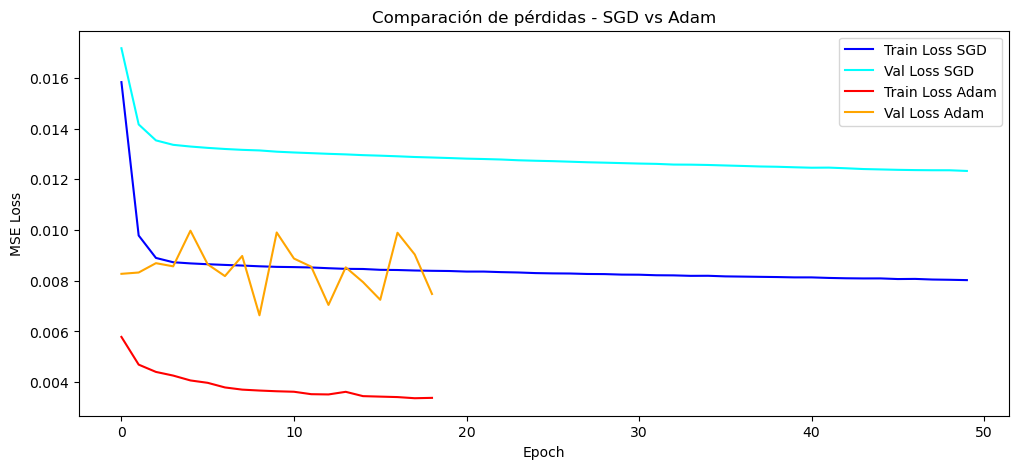

In [119]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(hist_sgd['train_loss'], label='Train Loss SGD', color='blue')
plt.plot(hist_sgd['val_loss'], label='Val Loss SGD', color='cyan')
plt.plot(hist_adam['train_loss'], label='Train Loss Adam', color='red')
plt.plot(hist_adam['val_loss'], label='Val Loss Adam', color='orange')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Comparación de pérdidas - SGD vs Adam')
plt.legend()
plt.show()

podemos ver que el optimizador adam, requiere menos epoch para llegar a un resultado

#### Esta función nos ayuda  a evaluar el modelo

In [120]:
model.eval()
X_test_tensor = torch.from_numpy(X_test_norm.values).float().cuda()
with torch.no_grad():
    y_pred_norm = model(X_test_tensor)

#### Generamos la gráfica del modelo en base a nuestros valores predichos, con los reales

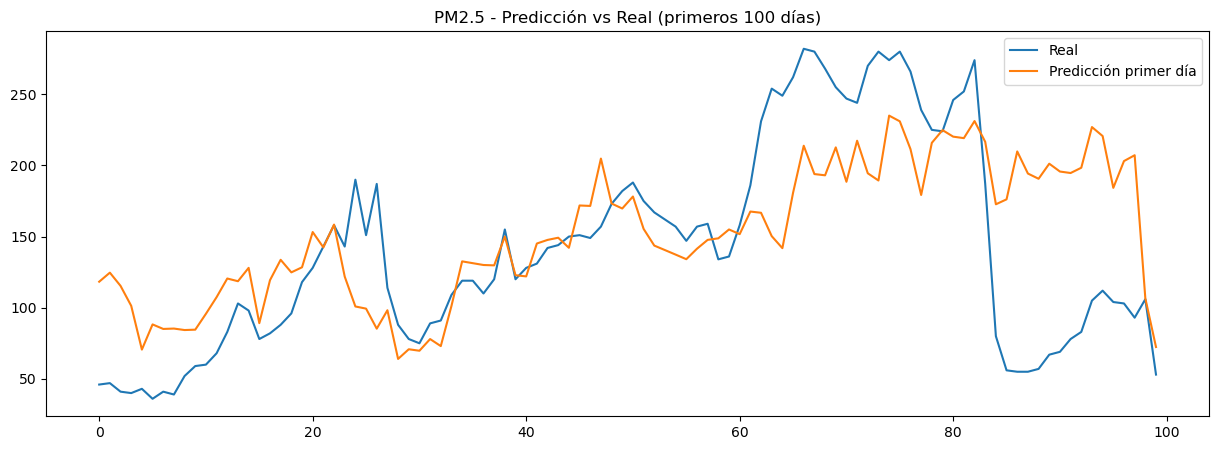

In [121]:
import matplotlib.pyplot as plt
y_pred = y_pred_norm.cpu().numpy() * (y_max - y_min) + y_min
y_true = y_test.values

plt.figure(figsize=(15,5))
plt.plot(y_true[:100], label="Real")
plt.plot(y_pred[:100,0], label="Predicción primer día")
plt.legend()
plt.title("PM2.5 - Predicción vs Real (primeros 100 días)")
plt.show()

en base a la gráfica podemos ver, que el modelo predice  con una buena precisión, nuestra gráfica muestra como se comporta el modelo a 100 dias de predicción